In [1]:


import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils, models

from tqdm import tqdm
from scipy import linalg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

BASE_DIR = Path(".")
CKPT_DIR = BASE_DIR / "checkpoints_dcgan_clean"
SAMPLE_DIR = BASE_DIR / "samples_dcgan_clean"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

image_size = 64
latent_dim = 100          # z dimension
batch_size = 128
num_epochs = 50
lr = 2e-4
beta1 = 0.5


Using device: cuda


In [2]:


transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of training images:", len(train_dataset))


100%|██████████| 170M/170M [00:03<00:00, 51.8MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Number of training images: 50000


/home/parthip/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [3]:


class GeneratorNet(nn.Module):
    """
    DCGAN-style generator: z -> 3x64x64
    """
    def __init__(self, z_dim=latent_dim, base_ch=64):
        super().__init__()
        self.model = nn.Sequential(
            # input: (z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, base_ch * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),   # output range [-1, 1]
        )

    def forward(self, z):
        return self.model(z)


class DiscriminatorNet(nn.Module):
    """
    DCGAN-style discriminator: 3x64x64 -> probability scalar
    """
    def __init__(self, base_ch=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, base_ch, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 2, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 4, base_ch * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.model(x)
        return out.view(-1)   # (batch,)


def dcgan_weight_init(m: nn.Module):
    """
    Heavily inspired by the original DCGAN initialization.
    """
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
        nn.init.constant_(m.bias.data, 0.0)


# Instantiate models
G = GeneratorNet().to(device)
D = DiscriminatorNet().to(device)

G.apply(dcgan_weight_init)
D.apply(dcgan_weight_init)

print(G)
print(D)


GeneratorNet(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  

In [4]:


criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))


class InceptionBackbone(nn.Module):
    """
    Wrap torchvision's inception_v3 to output 2048-d features
    (after global average pooling).
    """
    def __init__(self):
        super().__init__()
        backbone = models.inception_v3(pretrained=True, transform_input=False)
        backbone.fc = nn.Identity()
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False
        self.backbone = backbone

    @torch.no_grad()
    def forward(self, x):
        # expect x in [0,1] resized to 299x299
        return self.backbone(x)


fid_net = InceptionBackbone().to(device)
print("Inception backbone ready for FID.")


/home/parthip/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/parthip/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception backbone ready for FID.


In [5]:


def to_inception_space(imgs: torch.Tensor) -> torch.Tensor:
    """
    imgs: tensor in [-1,1], shape (N,3,H,W)
    -> normalize to [0,1] and resize to 299x299 for Inception.
    """
    imgs = (imgs + 1.0) / 2.0
    imgs = F.interpolate(imgs, size=(299, 299),
                         mode="bilinear", align_corners=False)
    return imgs


def get_feature_stats(batch: torch.Tensor, model: nn.Module):
    """
    Compute mean and covariance of features for a given batch of images.
    """
    model.eval()
    with torch.no_grad():
        feats = model(to_inception_space(batch.to(device))).cpu().numpy()
    mu = np.mean(feats, axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma


def frechet_distance(mu1, sigma1, mu2, sigma2):
    """
    Standard Fréchet distance between two Gaussians.
    """
    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)
    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    tr_covmean = np.trace(covmean)
    fid = diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean
    return float(fid)


def quick_batch_fid(real_imgs, fake_imgs, model):
    """
    Single-batch approximate FID (like your friend's per-epoch FID).
    """
    mu_r, sig_r = get_feature_stats(real_imgs, model)
    mu_f, sig_f = get_feature_stats(fake_imgs, model)
    return frechet_distance(mu_r, sig_r, mu_f, sig_f)


In [6]:


fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

G_losses = []
D_losses = []
fid_estimates = []

def denorm(x):
    # From [-1,1] to [0,1]
    return (x + 1.0) / 2.0

for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()

    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for real, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}"):
        real = real.to(device)
        bs = real.size(0)

        # Labels
        real_labels = torch.ones(bs, device=device)
        fake_labels = torch.zeros(bs, device=device)

        # ----------- Train Discriminator -----------
        z = torch.randn(bs, latent_dim, 1, 1, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D_real = criterion(out_real, real_labels)
        loss_D_fake = criterion(out_fake, fake_labels)
        loss_D = 0.5 * (loss_D_real + loss_D_fake)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ----------- Train Generator -----------
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    # Average losses over the epoch
    epoch_loss_G /= len(train_loader)
    epoch_loss_D /= len(train_loader)
    G_losses.append(epoch_loss_G)
    D_losses.append(epoch_loss_D)

    # Quick FID using a fresh small batch
    G.eval()
    with torch.no_grad():
        real_batch, _ = next(iter(train_loader))
        real_batch = real_batch.to(device)
        noise = torch.randn(real_batch.size(0), latent_dim, 1, 1, device=device)
        fake_batch = G(noise)

    fid_approx = quick_batch_fid(denorm(real_batch), denorm(fake_batch), fid_net)
    fid_estimates.append(fid_approx)

    print(f"[Epoch {epoch}/{num_epochs}] "
          f"D Loss: {epoch_loss_D:.4f} | G Loss: {epoch_loss_G:.4f} | quick FID: {fid_approx:.2f}")

    # Save sample grid
    with torch.no_grad():
        sample_imgs = G(fixed_noise).detach().cpu()
    utils.save_image(sample_imgs, SAMPLE_DIR / f"epoch_{epoch}.png", normalize=True)

    # Save checkpoints
    torch.save(G.state_dict(), CKPT_DIR / f"G_epoch_{epoch}.pth")
    torch.save(D.state_dict(), CKPT_DIR / f"D_epoch_{epoch}.pth")


Epoch 1/50: 100%|██████████| 391/391 [00:12<00:00, 30.63it/s]


[Epoch 1/50] D Loss: 0.2850 | G Loss: 7.2011 | quick FID: 350.58


Epoch 2/50: 100%|██████████| 391/391 [00:10<00:00, 37.83it/s]


[Epoch 2/50] D Loss: 0.3440 | G Loss: 4.0133 | quick FID: 432.79


Epoch 3/50: 100%|██████████| 391/391 [00:10<00:00, 38.66it/s]


...

[Epoch 48/50] D Loss: 0.2497 | G Loss: 3.7564 | quick FID: 79.53


Epoch 49/50: 100%|██████████| 391/391 [00:10<00:00, 38.47it/s]


[Epoch 49/50] D Loss: 0.2320 | G Loss: 4.0076 | quick FID: 79.05


Epoch 50/50: 100%|██████████| 391/391 [00:10<00:00, 38.79it/s]


[Epoch 50/50] D Loss: 0.2833 | G Loss: 3.1037 | quick FID: 69.30


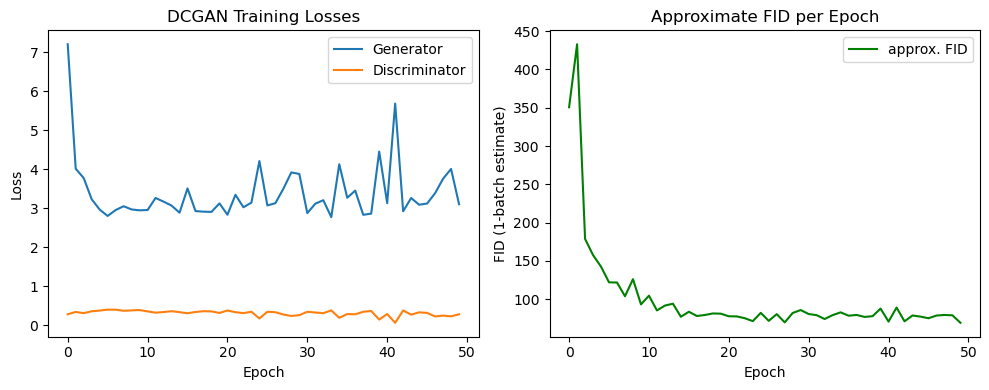

In [7]:


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("DCGAN Training Losses")

plt.subplot(1, 2, 2)
plt.plot(fid_estimates, label="approx. FID", color="green")
plt.xlabel("Epoch")
plt.ylabel("FID (1-batch estimate)")
plt.legend()
plt.title("Approximate FID per Epoch")

plt.tight_layout()
plt.show()


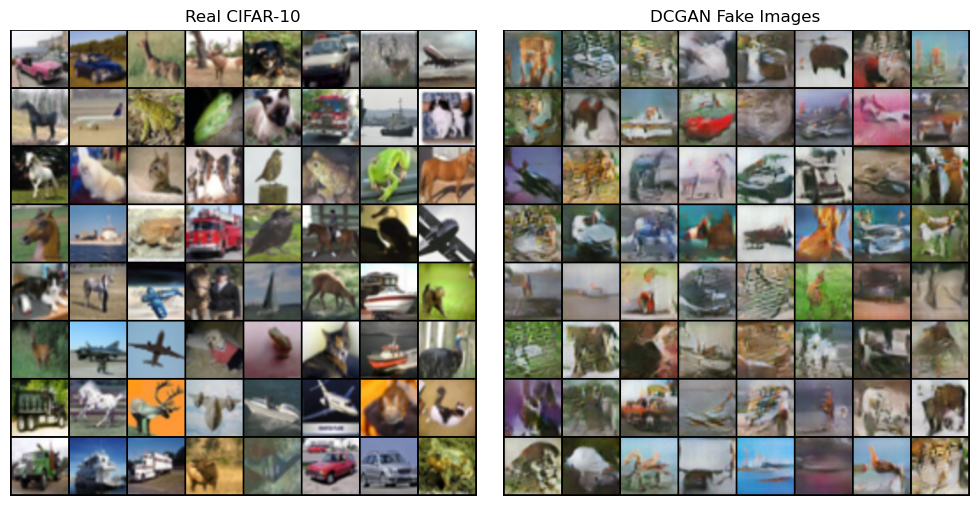

In [8]:


import torchvision.utils as vutils

G.eval()

real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:64].to(device)

with torch.no_grad():
    fake_batch = G(fixed_noise).detach().cpu()

real_batch = real_batch.cpu()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    np.transpose(
        vutils.make_grid(real_batch, padding=2, normalize=True), (1, 2, 0)
    )
)
axes[0].set_title("Real CIFAR-10")
axes[0].axis("off")

axes[1].imshow(
    np.transpose(
        vutils.make_grid(fake_batch, padding=2, normalize=True), (1, 2, 0)
    )
)
axes[1].set_title("DCGAN Fake Images")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Files already downloaded and verified

📊 DCGAN Evaluation
FID (1000 samples): 77.82
Inception Score: 2.34 ± 0.19


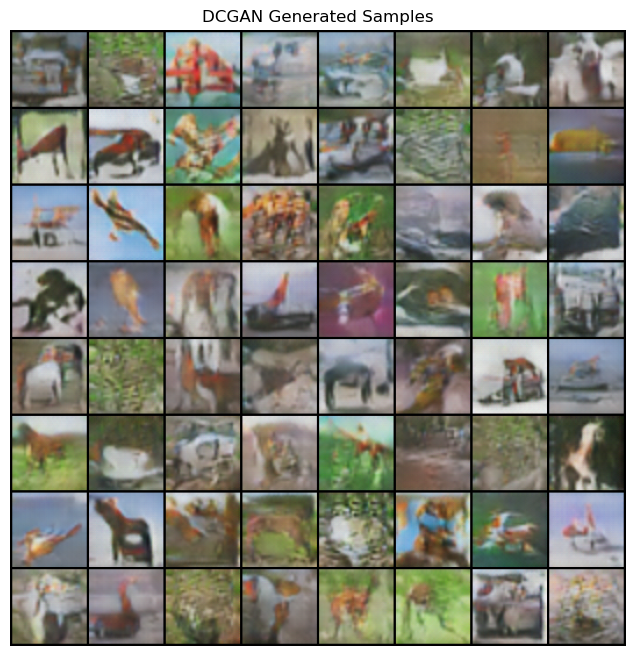

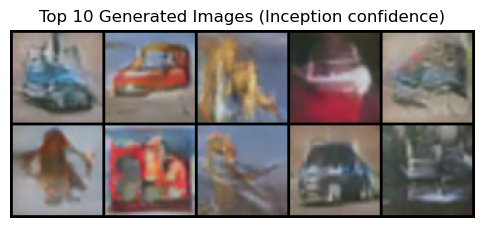

Top-10 Inception confidences: [0.99325246 0.9917698  0.9896584  0.98487353 0.9846868  0.9829342
 0.98253834 0.97767216 0.97527313 0.97129446]


In [9]:


from torchvision.models import inception_v3
from torchvision.utils import make_grid

# Evaluation dataset (test split)
eval_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=True, num_workers=2)


@torch.no_grad()
def inception_features(images, inc_model):
    """Get 2048-d inception features for a batch in [-1,1]."""
    imgs = (images + 1.0) / 2.0
    imgs = F.interpolate(imgs, size=(299, 299),
                         mode="bilinear", align_corners=False)
    feats = inc_model(imgs)
    return feats.cpu().numpy()


def compute_fid(generator, real_loader, n_samples=1000, z_dim=latent_dim):
    inc = inception_v3(pretrained=True, transform_input=False).to(device)
    inc.fc = nn.Identity()
    inc.eval()

    # Real features
    real_feats = []
    count = 0
    for imgs, _ in real_loader:
        imgs = imgs.to(device)
        feats = inception_features(imgs, inc)
        real_feats.append(feats)
        count += imgs.size(0)
        if count >= n_samples:
            break
    real_feats = np.concatenate(real_feats, axis=0)[:n_samples]
    mu_r = real_feats.mean(axis=0)
    sig_r = np.cov(real_feats, rowvar=False)

    # Fake features
    fake_feats = []
    count = 0
    while count < n_samples:
        bs = min(64, n_samples - count)
        z = torch.randn(bs, z_dim, 1, 1, device=device)
        fake_imgs = generator(z)
        feats = inception_features(fake_imgs, inc)
        fake_feats.append(feats)
        count += bs
    fake_feats = np.concatenate(fake_feats, axis=0)[:n_samples]
    mu_f = fake_feats.mean(axis=0)
    sig_f = np.cov(fake_feats, rowvar=False)

    return frechet_distance(mu_r, sig_r, mu_f, sig_f)


def compute_inception_score(generator, n_images=1000, splits=10, z_dim=latent_dim):
    inc = inception_v3(pretrained=True, transform_input=False).to(device)
    inc.eval()

    preds = []
    with torch.no_grad():
        count = 0
        while count < n_images:
            bs = min(64, n_images - count)
            z = torch.randn(bs, z_dim, 1, 1, device=device)
            fake = generator(z)
            imgs = (fake + 1.0) / 2.0
            imgs = F.interpolate(imgs, size=(299, 299),
                                 mode="bilinear", align_corners=False)
            logits = inc(imgs)
            prob = F.softmax(logits, dim=1)
            preds.append(prob.cpu().numpy())
            count += bs

    preds = np.concatenate(preds, axis=0)
    N = preds.shape[0]
    split_scores = []

    for k in range(splits):
        part = preds[k * (N // splits):(k + 1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores = [np.sum(pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8)))
                  for pyx in part]
        split_scores.append(np.exp(np.mean(scores)))

    return float(np.mean(split_scores)), float(np.std(split_scores))



G.eval()
fid_value = compute_fid(G, eval_loader, n_samples=1000)
is_mean, is_std = compute_inception_score(G, n_images=1000, splits=10)

print("\n📊 DCGAN Evaluation")
print(f"FID (1000 samples): {fid_value:.2f}")
print(f"Inception Score: {is_mean:.2f} ± {is_std:.2f}")



with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1, device=device)
    fake_images = G(noise)
fake_vis = (fake_images + 1.0) / 2.0

grid = make_grid(fake_vis, nrow=8)
npimg = grid.cpu().numpy()
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title("DCGAN Generated Samples")
plt.axis("off")
plt.show()



@torch.no_grad()
def topk_generated_images(generator, k=10, candidates=2048):
    inc_cls = inception_v3(pretrained=True, transform_input=False).to(device)
    inc_cls.eval()

    all_imgs = []
    all_scores = []

    count = 0
    while count < candidates:
        bs = min(64, candidates - count)
        z = torch.randn(bs, latent_dim, 1, 1, device=device)
        fake = generator(z)                      # [-1,1]
        imgs_01 = (fake + 1.0) / 2.0
        resized = F.interpolate(imgs_01, size=(299, 299),
                                mode="bilinear", align_corners=False)
        logits = inc_cls(resized)
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)              # confidence per image

        all_imgs.append(fake.cpu())
        all_scores.append(conf.cpu())
        count += bs

    all_imgs = torch.cat(all_imgs, dim=0)
    all_scores = torch.cat(all_scores, dim=0)

    top_conf, top_idx = torch.topk(all_scores, k)
    best_imgs = all_imgs[top_idx]               # [-1,1]

    vis = (best_imgs + 1.0) / 2.0
    grid = make_grid(vis, nrow=5)
    npimg = grid.numpy()

    utils.save_image(vis, SAMPLE_DIR / "top10_best_dcgan.png", nrow=5)

    plt.figure(figsize=(6, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title("Top 10 Generated Images (Inception confidence)")
    plt.axis("off")
    plt.show()

    print("Top-10 Inception confidences:", top_conf.numpy())


topk_generated_images(G, k=10, candidates=2048)
